<a href="https://colab.research.google.com/github/bagadevaishnavi760-collab/Marketing_agency_customer-churn-prediction/blob/main/Marketing_agency_Customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Marketing Agency Customer Churn





---




# Content

---


The data is saved as customer_churn.csv. Here are the fields and their definitions:

Name : Name of the latest contact at Company

Age: Customer Age

Total_Purchase: Total Ads Purchased

Account_Manager: Binary 0=No manager, 1= Account manager assigned

Years: Totaly Years as a customer

Num_sites: Number of websites that use the service.

Onboard_date: Date that the name of the latest contact was onboarded

Location: Client HQ Address

Company: Name of Client Company

# Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,balanced_accuracy_score,classification_report,
    confusion_matrix,precision_score,roc_auc_score,RocCurveDisplay,
    recall_score,f1_score
)


# Upload the Dataset

In [43]:
df = pd.read_csv("/content/customer_churn.csv",encoding="utf-8-sig")

In [44]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


# Data Preprocessing

In [45]:
df.shape

(900, 10)

In [46]:
df.columns.tolist()

['Names',
 'Age',
 'Total_Purchase',
 'Account_Manager',
 'Years',
 'Num_Sites',
 'Onboard_date',
 'Location',
 'Company',
 'Churn']

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [48]:
display(df.describe(include= "all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Names,900,899,Jennifer Wood,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,900.0,NaN,NaN,NaN,41.816667,6.12756,22.0,38.0,42.0,46.0,65.0
Total_Purchase,900.0,NaN,NaN,NaN,10062.824033,2408.644532,100.0,8497.1225,10045.87,11760.105,18026.01
Account_Manager,900.0,NaN,NaN,NaN,0.481111,0.499921,0.0,0.0,0.0,1.0,1.0
Years,900.0,NaN,NaN,NaN,5.273156,1.274449,1.0,4.45,5.215,6.11,9.15
Num_Sites,900.0,NaN,NaN,NaN,8.587778,1.764836,3.0,7.0,8.0,10.0,14.0
Onboard_date,900,900,2010-09-25 12:16:08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,900,900,"27252 Olivia Burgs Rivasmouth, MN 80121-6348",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,900,873,Anderson Group,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,900.0,NaN,NaN,NaN,0.166667,0.372885,0.0,0.0,0.0,0.0,1.0


# Check for missing values

In [49]:
df.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


no missing or null value found

In [50]:
df.nunique()

,0
Names,899
Age,36
Total_Purchase,900
Account_Manager,2
Years,418
Num_Sites,12
Onboard_date,900
Location,900
Company,873
Churn,2


Name has 899 unique values among 900 records, so it acts like a customer identifier and provides no meaningful general pattern for predicting churn. Keeping it could make the model memorise customers and overfit.

Company: 873 unique values, so it is also almost an identifier.


Location: 900 unique full addresses.

In [51]:
df.drop(columns=["Names","Company","Location"],inplace=True)

Extracting useful features from Onboard_date and then dropping it
`

In [52]:
df["Onboard_date"] = pd.to_datetime(
    df["Onboard_date"],
    errors="coerce"
)

df["Onboard_Year"] = df["Onboard_date"].dt.year
df["Onboard_Month"] = df["Onboard_date"].dt.month

df.drop(columns=["Onboard_date"], inplace=True)

In [53]:
df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn,Onboard_Year,Onboard_Month
0,42.0,11066.80,0,7.22,8.0,1,2013,8
1,41.0,11916.22,0,6.50,11.0,1,2013,8
2,38.0,12884.75,0,6.67,12.0,1,2016,6
3,42.0,8010.76,0,6.71,10.0,1,2014,4
4,37.0,9191.58,0,5.56,9.0,1,2016,1


Check that all columns are numerical:

In [54]:
object_columns = df.select_dtypes(include="object").columns.tolist()
print(object_columns)

[]


All the columns are therefore numerical
`

# Check for duplicate values

---



In [55]:
df.duplicated().sum()

np.int64(0)

no duplicate value found

In [56]:
print("Churn Distribution")
print(df['Churn'].value_counts())

Churn Distribution
Churn
0    750
1    150
Name: count, dtype: int64


0 = customer did not leave

1 = customer churned

this is an imbalanced binary classification problem

In [57]:
print("Churn percentage")
print(df['Churn'].value_counts(normalize = True)*100)

Churn percentage
Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64


# Visualizing the target distribution

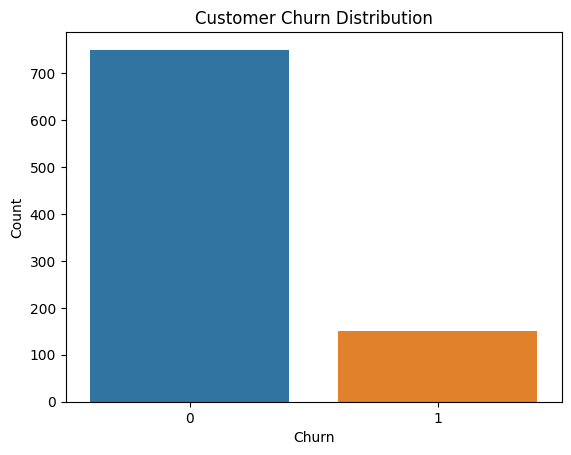

In [58]:
sns.countplot(data=df,x="Churn",hue="Churn",legend=False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The plot above clearly shows an imbalanced distribution for customer churn. The number of customers who did not churn (represented by 0) is significantly higher than those who did churn (represented by 1). This imbalance is important to note as it can affect the performance of machine learning models trained on this data.

# seperate features and target

In [59]:
x = df.drop(columns=["Churn"])
y = df["Churn"]
feature_columns = x.columns.tolist()
print("\nModel features:",feature_columns)
print("\nTarget:",y.name)
print("Target Distribution:")
print(y.value_counts(normalize=True))


Model features: ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites', 'Onboard_Year', 'Onboard_Month']

Target: Churn
Target Distribution:
Churn
0    0.833333
1    0.166667
Name: proportion, dtype: float64


In [61]:
date_features =[
    "Onboard_Year",
    "Onboard_Month",

]
print(df[date_features].isnull().sum())
print("\n",df[date_features].nunique())
display(df[date_features].describe())

Onboard_Year     0
Onboard_Month    0
dtype: int64

 Onboard_Year     11
Onboard_Month    12
dtype: int64


,Onboard_Year,Onboard_Month
count,900.000000,900.000000
mean,2010.801111,6.204444
std,3.207229,3.491668
min,2006.000000,1.000000
25%,2008.000000,3.000000
50%,2011.000000,6.000000
75%,2014.000000,9.000000
max,2016.000000,12.000000


# Onboarding year distribution


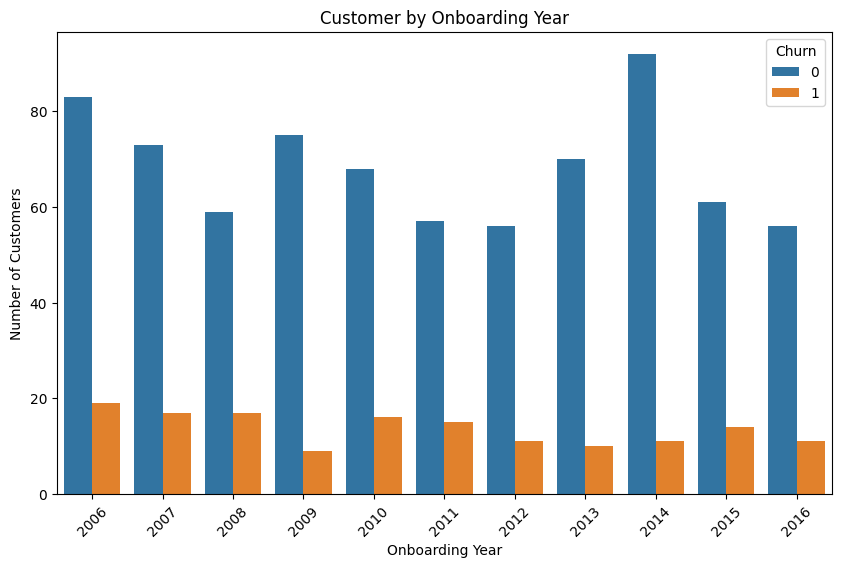

In [62]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Onboard_Year", hue="Churn")
plt.title("Customer by Onboarding Year")
plt.xlabel("Onboarding Year")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

Earlier cohorts (especially 2006) appear to churn at a higher rate than later ones like 2014, hinting that either retention efforts improved over time or newer customers (as of the data's cutoff) simply haven't had as long to churn

# Churn rate by Onboarding year

In [63]:
year_churn=( df.groupby("Onboard_Year")["Churn"]
.agg(Customer_Count="count",Churn_Rate="mean")
.reset_index()
)
year_churn["Churn_Rate"]*=100
display(year_churn)

,Onboard_Year,Customer_Count,Churn_Rate
0,2006,102,18.627451
1,2007,90,18.888889
2,2008,76,22.368421
3,2009,84,10.714286
4,2010,84,19.047619
5,2011,72,20.833333
6,2012,67,16.417910
7,2013,80,12.500000
8,2014,103,10.679612
9,2015,75,18.666667


certain years, like 2008, 2010, and 2011, had higher churn rates compared to others, such as 2009, 2013, and 2014, which show lower churn rates. This suggests that factors related to the onboarding year might influence customer retention.

# Analyse onboarding month

In [64]:
month_churn = (
    df.groupby("Onboard_Month")["Churn"]
      .agg(Customer_Count="count", Churn_Rate="mean")
      .reset_index()
)

month_churn["Churn_Rate"] *= 100

display(month_churn)

,Onboard_Month,Customer_Count,Churn_Rate
0,1,90,15.555556
1,2,74,18.918919
2,3,106,20.754717
3,4,71,14.084507
4,5,67,10.447761
5,6,72,11.111111
6,7,68,17.647059
7,8,76,14.473684
8,9,70,11.428571
9,10,70,22.857143


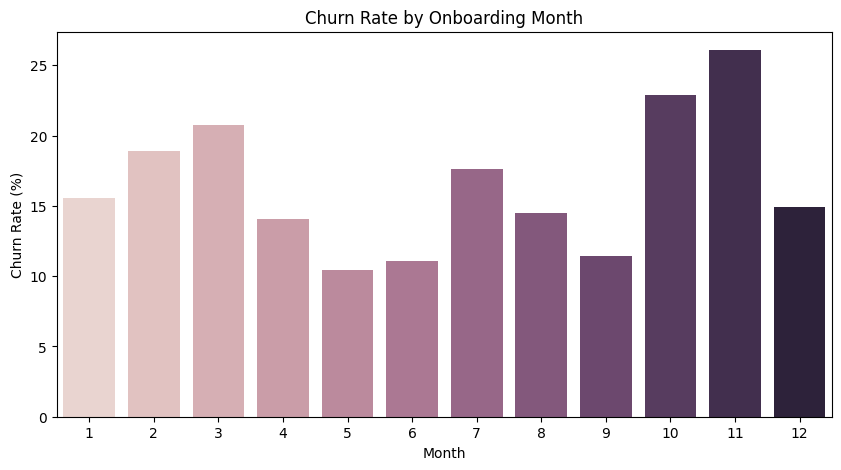

In [65]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=month_churn,
    x="Onboard_Month",
    y="Churn_Rate",
    hue="Onboard_Month",
    legend=False
)

plt.title("Churn Rate by Onboarding Month")
plt.xlabel("Month")
plt.ylabel("Churn Rate (%)")
plt.show()

Customers onboarded in October–November churn at more than double the rate of those onboarded in May–June. This could point to:

Seasonal acquisition campaigns (e.g., holiday promotions) bringing in lower-intent or discount-driven customers who churn faster.

Differences in onboarding quality, support load, or pricing changes during that period.

External factors (e.g., a product/plan change or a bad cohort) if this is a single year's data rather than an average across years.

# Define features and target

In [68]:
selected_features = [
    "Age",
    "Total_Purchase",
    "Account_Manager",
    "Years",
    "Num_Sites",
    "Onboard_Year",
    "Onboard_Month"
]

X = df[selected_features]
y = df["Churn"]

# Examine the class imbalance

In [69]:
target_summary = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

display(target_summary.round(2))

,Count,Percentage
Churn,,
0,750,83.33
1,150,16.67


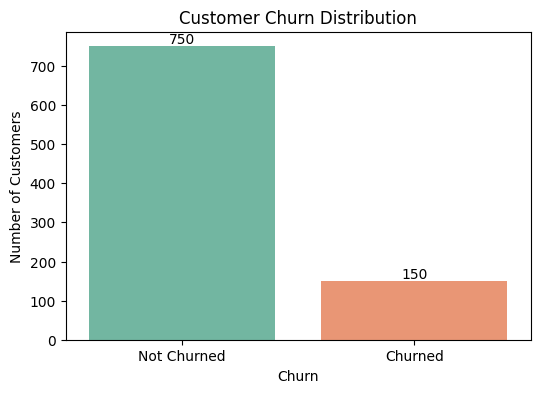

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x=y,
    hue=y,
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Not Churned", "Churned"])
plt.show()

moderately imbalanced dataset: the "Not Churned" class is 5x larger than the "Churned" class.

If a model just predicted "Not Churned" for every customer, it would still be 83.3% accurate — which is why accuracy alone is a misleading metric here, and stratified splitting + class-imbalance handling is needed while building a churn prediction model.

# Stratified train-test split


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training distribution:
Churn
0    600
1    120
Name: count, dtype: int64
Churn
0    83.33
1    16.67
Name: proportion, dtype: float64

Testing distribution:
Churn
0    150
1     30
Name: count, dtype: int64
Churn
0    83.33
1    16.67
Name: proportion, dtype: float64


# cross-validation strategy

In [72]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)